### Without using any LLM

In [74]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict

In [75]:
# Define the state
# Define State
class EmployeeState(TypedDict):

    employee_name: str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str

In [76]:
# Node 1 - Calculate Yearly Salary

def calculate_yearly_salary(state: EmployeeState) -> EmployeeState:
    yearly_salary = state['monthly_salary'] * 12
    state['yearly_salary'] = yearly_salary
    return state

In [77]:
# Node 2 - Calculate Bonus

def calculate_bonus(state: EmployeeState) -> EmployeeState:
    bonus_amount = state['monthly_salary'] * 2
    state['bonus_amount'] = bonus_amount
    return state

In [78]:
# Node 3 - Project Evaluation

def project_evaluation(state: EmployeeState) -> EmployeeState:
    if state['completed_projects'] >= 5:
        status = 'Excellent'
    else:
        status = 'Average'
    
    state['project_status'] = status
    return state

In [79]:
# Node 4 - Summary

def create_summary(state: EmployeeState) -> EmployeeState:

    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and a bonus of {state['bonus_amount']}. Project status is {state['project_status']}."

    state['summary'] = summary_text

    return state

In [80]:
graph = StateGraph(EmployeeState)

# Add Nodes
graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('calculate_bonus', calculate_bonus)
graph.add_node('project_evaluation', project_evaluation)
graph.add_node('create_summary', create_summary)

# Add Edges
graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'project_evaluation')

graph.add_edge('calculate_yearly_salary', 'create_summary')
graph.add_edge('calculate_bonus', 'create_summary')
graph.add_edge('project_evaluation', 'create_summary')
graph.add_edge('create_summary', END)

workflow = graph.compile()

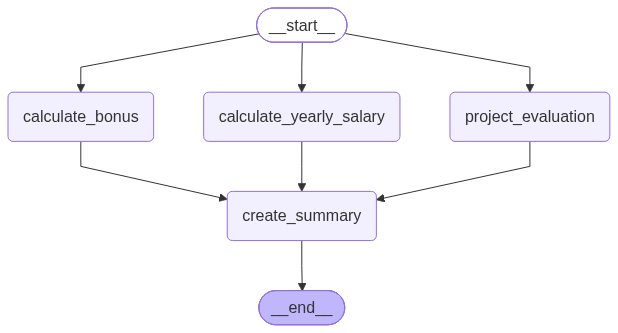

In [81]:
workflow

# or use 
# Visulise this graph
# from IPython.display import Image
# Image(workflow.get_graph().draw_mermaid_png())


In [82]:
# Initial Input

initial_state = {
    'employee_name': 'Bappy',
    'monthly_salary': 50000,
    'working_days': 26,
    'completed_projects': 7
}

# Run Workflow
result = workflow.invoke(initial_state)

InvalidUpdateError: At key 'employee_name': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [ ]:
# refer this for this error: https://youtu.be/4RtKGasvNC0?si=luiAmDARlSQEN-j1&t=34609

# In parallel workflow, return only that variable or state in which changes are made not the whole state.

In [83]:
# Node 1 - Calculate Yearly Salary

def calculate_yearly_salary(state: EmployeeState):
    yearly_salary = state['monthly_salary'] * 12
    return{ 
        'yearly_salary': yearly_salary
    }

# so we dont need the return type of EmployeeState also(-> EmployeeState:). 

In [84]:
# Node 2 - Calculate Bonus

def calculate_bonus(state: EmployeeState):
    bonus_amount = state['monthly_salary'] * 2
    return {
        'bonus_amount': bonus_amount
    }

In [85]:
# Node 3 - Project Evaluation

def project_evaluation(state: EmployeeState):
    if state['completed_projects'] >= 5:
        status = 'Excellent'
    else:
        status = 'Average'

    return{
        'project_status': status
    }

In [86]:
# Node 4 - Summary

def create_summary(state: EmployeeState) -> EmployeeState:

    summary_text = f"Employee {state['employee_name']} has a yearly salary of {state['yearly_salary']} and a bonus of {state['bonus_amount']}. Project status is {state['project_status']}."

    return{
        'summary': summary_text
    }

In [89]:
# Initial Input

initial_state = {
    'employee_name': 'Bappy',
    'monthly_salary': 50000,
    'working_days': 26,
    'completed_projects': 7
}

# Run Workflow
result = workflow.invoke(initial_state)

InvalidUpdateError: At key 'employee_name': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE

In [88]:
result

{'employee_name': 'Bappy',
 'monthly_salary': 50000,
 'working_days': 26,
 'completed_projects': 7,
 'yearly_salary': 600000,
 'bonus_amount': 100000,
 'project_status': 'Excellent',
 'summary': 'Employee Bappy has a yearly salary of 600000 and a bonus of 100000. Project status is Excellent.'}

### Parallel Workflow using LLM - Essay workflow
- for working refer it: https://youtu.be/4RtKGasvNC0?si=Dqv_Ts3tVJB6hSx7&t=35224

In [90]:
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
from langchain_groq import ChatGroq
import operator 

In [91]:
load_dotenv()

True

In [149]:
llm = ChatGroq(
    model = "openai/gpt-oss-20b"
)

In [150]:
# making a structured output using pydantic as LLM may generate unstructured output.
from pydantic import BaseModel, Field

class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: float = Field(
        description="Score out of 10",
        ge=0,
        le=10
    )

    # ge = greator than
    # le = lesser than


In [ ]:
structured_llm = llm.with_structured_output(EvaluationSchema)

In [156]:
structured_llm
# so from now we will use this structured_llm instead of llm 

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B872A42B70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B86F763E00>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'EvaluationSchema', 'description': '', 'parameters': {'properties': {'feedback': {'descript

In [157]:
essay = """The AI Revolution in India

Artificial intelligence has moved, within a decade, from a research curiosity to a force reshaping how India works, governs, and builds. What began as a handful of academic labs and outsourced R&D units for global tech firms has become a full domestic ecosystem — one now producing its own models, platforms, and talent rather than only consuming technology built elsewhere.

From Services to Systems

India's tech industry built its global reputation on IT services — writing and maintaining software for the world. AI is changing the shape of that industry. Companies that once billed by the hour for coding and support are now building AI products: automated customer service systems, fraud-detection engines for banks, diagnostic tools for hospitals, and yield-optimization models for farms. The shift is from services to systems — from doing work for clients to building intelligence that does work on its own.

This shift is visible in the startup landscape too. AI-focused startups in India have moved past simple chatbots into harder problems: regional-language models that work in Hindi, Tamil, and a dozen other languages; retrieval-based systems that let businesses query their own data in plain language; and evaluation tools that measure whether these systems are actually reliable before they reach real users.

Government and Infrastructure

India's AI push has not been left to the private sector alone. The IndiaAI Mission, the push for a sovereign large language model, and continued investment in Digital Public Infrastructure (building on the success of Aadhaar and UPI) reflect a deliberate state strategy: don't just use AI built elsewhere, build the compute, data, and models domestically. This matters because a country that only consumes AI has little say in how it is shaped, governed, or made safe.

The Talent Engine

Perhaps the most distinct feature of India's AI moment is scale of talent. Millions of engineering graduates enter the workforce each year, and a growing share are trained specifically in machine learning, natural language processing, and applied AI rather than general software development. University coursework increasingly includes retrieval-augmented generation, model evaluation, and agentic systems — topics that, five years ago, existed mostly in research papers. This pipeline gives India a structural advantage: even if it does not lead in raw compute, it can lead in the number of people who know how to build with AI responsibly and well.

The Open Questions

The revolution is real, but it is not finished, and it is not free of tension. Access to large-scale compute remains a bottleneck. Rural and lower-income populations risk being left out of an AI-driven economy unless deliberate effort is made to include them. And as AI systems take on more consequential decisions — in lending, hiring, healthcare — the demand for rigorous evaluation and accountability grows just as fast as the demand for the systems themselves.

India's AI revolution, in the end, is not just a story about faster software. It is a story about a country deciding to build the intelligence it uses, train the people who build it, and — increasingly — hold it to account."""

In [158]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out ot 10 \n {essay}'

In [159]:
result = structured_llm.invoke(prompt)

In [160]:
result

EvaluationSchema(feedback='The essay demonstrates a solid command of English and is well‑structured, with clear headings and logical progression of ideas. The prose is concise and mostly free of grammatical errors, and the vocabulary is appropriate for a general‑audience business or policy piece. However, there are a few areas that could be strengthened: \n\n1. **Consistency in punctuation** – The use of em‑dashes and commas is sometimes uneven. For example, the opening sentence contains a comma after *decade* that feels unnecessary, and the sentence about “IndiaAI Mission” would read smoother with a hyphen or a space: *India AI Mission*.\n2. **Pronoun clarity** – The phrase “the shift is from services to systems — from doing work for clients to building intelligence that does work on its own” could be tightened to avoid the repetition of *work*.\n3. **Article usage** – In “the shift is from services to systems — from doing work for clients to building intelligence that does work on it

In [161]:
print(result.feedback)

The essay demonstrates a solid command of English and is well‑structured, with clear headings and logical progression of ideas. The prose is concise and mostly free of grammatical errors, and the vocabulary is appropriate for a general‑audience business or policy piece. However, there are a few areas that could be strengthened: 

1. **Consistency in punctuation** – The use of em‑dashes and commas is sometimes uneven. For example, the opening sentence contains a comma after *decade* that feels unnecessary, and the sentence about “IndiaAI Mission” would read smoother with a hyphen or a space: *India AI Mission*.
2. **Pronoun clarity** – The phrase “the shift is from services to systems — from doing work for clients to building intelligence that does work on its own” could be tightened to avoid the repetition of *work*.
3. **Article usage** – In “the shift is from services to systems — from doing work for clients to building intelligence that does work on its own,” the phrase “building in

In [162]:
print(result.score)

9.0


In [163]:
class EssayState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]  # reducer as we used Annonated
    avg_score: float

In [164]:
def evaluate_language(state: EssayState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10: {state["essay"]}'
    output = structured_llm.invoke(prompt)

    return {
        'language_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [165]:
def evaluate_analysis(state: EssayState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10: {state["essay"]}'
    output = structured_llm.invoke(prompt)

    return {
        'analysis_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [ ]:
def evaluate_thought(state: EssayState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10: {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {
        'clarity_feedback': output.feedback,
        'individual_scores': [output.score]
    }

In [172]:
def final_evaluation(state: EssayState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n analysis feedback - {state["analysis_feedback"]} \n clarity feedback - {state["clarity_feedback"]}'
    overall_feedback = structured_llm.invoke(prompt)

    # avg calculate
    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        'overall_feedback': overall_feedback,
        'avg_score': avg_score
    }

In [173]:
graph = StateGraph(EssayState)

# add nodes
graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# add edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

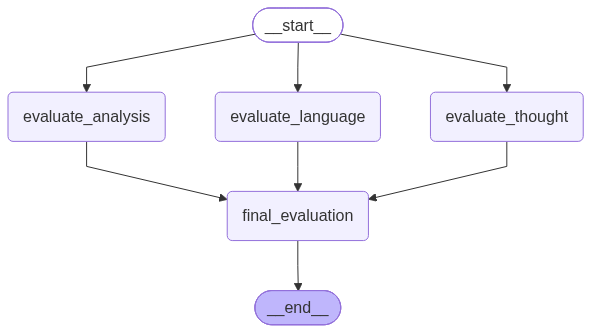

In [174]:
workflow

In [175]:
essay = """The AI Revolution in India

Artificial intelligence has moved, within a decade, from a research curiosity to a force reshaping how India works, governs, and builds. What began as a handful of academic labs and outsourced R&D units for global tech firms has become a full domestic ecosystem — one now producing its own models, platforms, and talent rather than only consuming technology built elsewhere.

From Services to Systems

India's tech industry built its global reputation on IT services — writing and maintaining software for the world. AI is changing the shape of that industry. Companies that once billed by the hour for coding and support are now building AI products: automated customer service systems, fraud-detection engines for banks, diagnostic tools for hospitals, and yield-optimization models for farms. The shift is from services to systems — from doing work for clients to building intelligence that does work on its own.

This shift is visible in the startup landscape too. AI-focused startups in India have moved past simple chatbots into harder problems: regional-language models that work in Hindi, Tamil, and a dozen other languages; retrieval-based systems that let businesses query their own data in plain language; and evaluation tools that measure whether these systems are actually reliable before they reach real users.

Government and Infrastructure

India's AI push has not been left to the private sector alone. The IndiaAI Mission, the push for a sovereign large language model, and continued investment in Digital Public Infrastructure (building on the success of Aadhaar and UPI) reflect a deliberate state strategy: don't just use AI built elsewhere, build the compute, data, and models domestically. This matters because a country that only consumes AI has little say in how it is shaped, governed, or made safe.

The Talent Engine

Perhaps the most distinct feature of India's AI moment is scale of talent. Millions of engineering graduates enter the workforce each year, and a growing share are trained specifically in machine learning, natural language processing, and applied AI rather than general software development. University coursework increasingly includes retrieval-augmented generation, model evaluation, and agentic systems — topics that, five years ago, existed mostly in research papers. This pipeline gives India a structural advantage: even if it does not lead in raw compute, it can lead in the number of people who know how to build with AI responsibly and well.

The Open Questions

The revolution is real, but it is not finished, and it is not free of tension. Access to large-scale compute remains a bottleneck. Rural and lower-income populations risk being left out of an AI-driven economy unless deliberate effort is made to include them. And as AI systems take on more consequential decisions — in lending, hiring, healthcare — the demand for rigorous evaluation and accountability grows just as fast as the demand for the systems themselves.

India's AI revolution, in the end, is not just a story about faster software. It is a story about a country deciding to build the intelligence it uses, train the people who build it, and — increasingly — hold it to account."""

In [176]:
initial_state ={
    'essay':  essay
}

result = workflow.invoke(initial_state)

In [179]:
result

{'essay': "The AI Revolution in India\n\nArtificial intelligence has moved, within a decade, from a research curiosity to a force reshaping how India works, governs, and builds. What began as a handful of academic labs and outsourced R&D units for global tech firms has become a full domestic ecosystem — one now producing its own models, platforms, and talent rather than only consuming technology built elsewhere.\n\nFrom Services to Systems\n\nIndia's tech industry built its global reputation on IT services — writing and maintaining software for the world. AI is changing the shape of that industry. Companies that once billed by the hour for coding and support are now building AI products: automated customer service systems, fraud-detection engines for banks, diagnostic tools for hospitals, and yield-optimization models for farms. The shift is from services to systems — from doing work for clients to building intelligence that does work on its own.\n\nThis shift is visible in the startup